# Vesuvius Surface Detection — Inference, Post-Processing & Visualization

**Pipeline:**
1. Run inference with individual models
2. Ensemble model probabilities (weighted fusion)
3. Post-processing: Hysteresis thresholding + Closing + Dust removal + Hole filling + PCA interpolation
4. Visual comparison & metrics

In [15]:
import sys, os

PROJECT_DIR = '/raid/home/vikram_govt/Dikshant/gautam/cv'
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

import numpy as np
import torch
import tifffile
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import csv
import scipy.ndimage as ndi
from scipy.ndimage import binary_closing, binary_fill_holes, binary_dilation, binary_erosion
from scipy.interpolate import griddata
from scipy.ndimage import median_filter, gaussian_filter, distance_transform_edt
from scipy.spatial import cKDTree
from skimage.measure import label, euler_number
from skimage.morphology import remove_small_objects, ball
from collections import deque

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Working dir:', os.getcwd())

## 1. Load Sample Volume

In [20]:
DATA_ROOT = Path('/raid/home/vikram_govt/Dikshant/gautam/cv/data')

val_ids = []
with open(DATA_ROOT / 'train.csv') as f:
    for row in csv.DictReader(f):
        if row['scroll_id'] == '26002':
            img_path = DATA_ROOT / 'train_images' / f'{row["id"]}.tif'
            if img_path.exists():
                val_ids.append(row['id'])

print(f'Found {len(val_ids)} validation volumes')
SAMPLE_ID = val_ids[0]
print(f'Using sample: {SAMPLE_ID}')

image = tifffile.imread(str(DATA_ROOT / 'train_images' / f'{SAMPLE_ID}.tif'))
label_gt = tifffile.imread(str(DATA_ROOT / 'train_labels' / f'{SAMPLE_ID}.tif'))
print(f'Image: {image.shape}, Label: {label_gt.shape}, Classes: {np.unique(label_gt)}')

## 2. Model Inference — Get Raw Probabilities

In [22]:
# --- Custom 3D U-Net ---
from src.models.unet3d import UNet3D
from src.utils.utils import load_config, get_gaussian_3d

def sliding_window_inference(model, volume_np, patch_size=128, overlap=0.5, num_classes=3):
    model.eval()
    volume = torch.from_numpy(volume_np.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)
    step = int(patch_size * (1 - overlap))
    D, H, W = volume.shape[2:]
    gaussian = get_gaussian_3d(patch_size).to(device)
    output_sum = torch.zeros(num_classes, D, H, W, device=device)
    weight_sum = torch.zeros(1, D, H, W, device=device)
    d_starts = list(range(0, max(D - patch_size, 0) + 1, step))
    h_starts = list(range(0, max(H - patch_size, 0) + 1, step))
    w_starts = list(range(0, max(W - patch_size, 0) + 1, step))
    if d_starts[-1] + patch_size < D: d_starts.append(D - patch_size)
    if h_starts[-1] + patch_size < H: h_starts.append(H - patch_size)
    if w_starts[-1] + patch_size < W: w_starts.append(W - patch_size)
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
        for d in d_starts:
            for h in h_starts:
                for w in w_starts:
                    patch = volume[:, :, d:d+patch_size, h:h+patch_size, w:w+patch_size]
                    logits = model(patch)['logits']
                    probs = torch.softmax(logits.float(), dim=1)[0]
                    output_sum[:, d:d+patch_size, h:h+patch_size, w:w+patch_size] += probs * gaussian
                    weight_sum[:, d:d+patch_size, h:h+patch_size, w:w+patch_size] += gaussian
    return (output_sum / weight_sum.clamp(min=1e-8)).cpu().numpy()

model_unet = UNet3D(1, 3, 32, [1,2,4,8,10], 2, True).to(device)
ckpt = torch.load('/raid/home/vikram_govt/Dikshant/gautam/cv/checkpoints/checkpoint_best.pth', map_location=device, weights_only=False)
model_unet.load_state_dict(ckpt['model_state_dict'])
model_unet.eval()
print(f'3D U-Net: epoch {ckpt["epoch"]}, best_surface_dice={ckpt["best_surface_dice"]:.4f}')

print('Running 3D U-Net inference...')
probs_unet = sliding_window_inference(model_unet, image)  # (3, D, H, W)
del model_unet; torch.cuda.empty_cache()
print('Done')

3D U-Net: epoch 450, best_surface_dice=0.2199
Running 3D U-Net inference...
Done


In [24]:
# --- nnU-Net models ---
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

os.environ['nnUNet_raw'] = 'nnUNet_data/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = 'nnUNet_data/nnUNet_preprocessed'
os.environ['nnUNet_results'] = 'nnUNet_data/nnUNet_results'

def run_nnunet_inference(model_dir, volume_np, folds='all', ckpt='checkpoint_best.pth'):
    predictor = nnUNetPredictor(
        tile_step_size=0.5, use_gaussian=True, use_mirroring=True,
        device=device, verbose=False,
    )
    predictor.initialize_from_trained_model_folder(
        model_dir, use_folds=(folds,) if isinstance(folds, str) else folds,
        checkpoint_name=ckpt,
    )
    img = volume_np.astype(np.float32)[np.newaxis]
    props = {'spacing': [1.0, 1.0, 1.0]}
    pred, probs = predictor.predict_single_npy_array(img, props, None, None, True)
    return probs  # (num_classes, D, H, W)

results_dir = Path('/raid/home/vikram_govt/Dikshant/gautam/cv/nnUNet_data/nnUNet_results/Dataset200_VesuviusSurface')

print('Running nnU-Net Default inference...')
probs_default = run_nnunet_inference(
    str(results_dir / 'nnUNetTrainer__nnUNetPlans__3d_fullres'), image)
torch.cuda.empty_cache()
print(f'  probs shape: {probs_default.shape}')

print('Running nnU-Net MPlans inference...')
probs_mplans = run_nnunet_inference(
    str(results_dir / 'nnUNetTrainer_4000epochs__nnUNetResEncUNetMPlans__3d_fullres'), image)
torch.cuda.empty_cache()
print(f'  probs shape: {probs_mplans.shape}')

print('Running nnU-Net LPlans inference...')
probs_lplans = run_nnunet_inference(
    str(results_dir / 'nnUNetTrainer_4000epochs__nnUNetResEncUNetLPlans__3d_fullres'), image)
torch.cuda.empty_cache()
print(f'  probs shape: {probs_lplans.shape}')

Running nnU-Net Default inference...


100%|██████████| 64/64 [00:28<00:00,  2.27it/s]


  probs shape: (3, 320, 320, 320)
Running nnU-Net MPlans inference...


100%|██████████| 64/64 [00:38<00:00,  1.67it/s]


  probs shape: (3, 320, 320, 320)
Running nnU-Net LPlans inference...


100%|██████████| 27/27 [00:48<00:00,  1.78s/it]


  probs shape: (3, 320, 320, 320)


## 3. Ensemble — Weighted Probability Fusion

Fuse the nnU-Net model probabilities with learned weights (following 1st/2nd place approaches).

In [25]:
# Ensemble weights (tuned by pseudo dice performance)
# Default(1000ep, finished) + MPlans(partial) + LPlans(partial)
W_DEFAULT = 0.4
W_MPLANS = 0.35
W_LPLANS = 0.25

probs_ensemble = (
    W_DEFAULT * probs_default +
    W_MPLANS * probs_mplans +
    W_LPLANS * probs_lplans
)

# Extract surface probability (class 1)
surf_prob_ensemble = probs_ensemble[1]
surf_prob_unet = probs_unet[1]

# Simple argmax predictions (no post-processing)
pred_raw_ensemble = probs_ensemble.argmax(axis=0)
pred_raw_unet = probs_unet.argmax(axis=0)

print(f'Ensemble surface prob range: [{surf_prob_ensemble.min():.4f}, {surf_prob_ensemble.max():.4f}]')
print(f'Raw ensemble classes: {np.unique(pred_raw_ensemble)}')

Ensemble surface prob range: [0.0000, 0.8774]
Raw ensemble classes: [0 1 2]


## 4. Post-Processing Pipeline

Based on 1st and 2nd place solutions:
1. **Hysteresis thresholding** on surface probability
2. **Anisotropic closing** to fill small holes
3. **Dust removal** (remove small components)
4. **Binary fill holes** per-slice and 3D
5. **PCA-based sheet interpolation** to repair large holes

In [26]:
# ================================================================
# POST-PROCESSING FUNCTIONS (from winning solutions)
# ================================================================

def build_anisotropic_struct(z_radius, xy_radius):
    z, r = z_radius, xy_radius
    if z == 0 and r == 0:
        return None
    if z == 0 and r > 0:
        size = 2 * r + 1
        struct = np.zeros((1, size, size), dtype=bool)
        cy, cx = r, r
        for dy in range(-r, r + 1):
            for dx in range(-r, r + 1):
                if dy * dy + dx * dx <= r * r:
                    struct[0, cy + dy, cx + dx] = True
        return struct
    if z > 0 and r == 0:
        struct = np.zeros((2 * z + 1, 1, 1), dtype=bool)
        struct[:, 0, 0] = True
        return struct
    depth = 2 * z + 1
    size = 2 * r + 1
    struct = np.zeros((depth, size, size), dtype=bool)
    cz, cy, cx = z, r, r
    for dz in range(-z, z + 1):
        for dy in range(-r, r + 1):
            for dx in range(-r, r + 1):
                if dy * dy + dx * dx <= r * r:
                    struct[cz + dz, cy + dy, cx + dx] = True
    return struct


def topo_postprocess(probs, T_low=0.2, T_high=0.83, z_radius=1, xy_radius=1, dust_min_size=2000):
    """Hysteresis thresholding + closing + dust removal (from 1st place)."""
    # Step 1: 3D Hysteresis thresholding
    strong = probs >= T_high
    weak = probs >= T_low
    if not strong.any():
        return np.zeros_like(probs, dtype=np.uint8)
    struct_hyst = ndi.generate_binary_structure(3, 3)
    mask = ndi.binary_propagation(strong, mask=weak, structure=struct_hyst)
    if not mask.any():
        return np.zeros_like(probs, dtype=np.uint8)
    
    # Step 2: Anisotropic closing
    struct_close = build_anisotropic_struct(z_radius, xy_radius)
    if struct_close is not None:
        mask = ndi.binary_closing(mask, structure=struct_close)
    
    # Step 3: Dust removal
    if dust_min_size > 0:
        mask = remove_small_objects(mask.astype(bool), min_size=dust_min_size)
    
    return mask.astype(np.uint8)


def zero_volume_faces(volume, thickness=3):
    """Set border voxels to 0 (label 2 region)."""
    result = volume.copy()
    result[:thickness, :, :] = 0
    result[-thickness:, :, :] = 0
    result[:, :thickness, :] = 0
    result[:, -thickness:, :] = 0
    result[:, :, :thickness] = 0
    result[:, :, -thickness:] = 0
    return result


def plug_small_holes_and_fill(mask):
    """Binary closing (radius 3) + per-slice fill + 3D fill (from 2nd place)."""
    # Binary closing with spherical footprint
    mask = ndi.binary_closing(mask, structure=ball(3))
    # Per-slice hole filling
    for z in range(mask.shape[0]):
        if mask[z].any():
            mask[z] = binary_fill_holes(mask[z])
    # 3D hole filling
    mask = binary_fill_holes(mask)
    return mask


def interpolate_sheet_component(component, grid_resolution=80, thickness=3, smoothing=1.5):
    """PCA-based sheet interpolation to repair holes (from 1st/2nd place).
    
    Projects component onto PCA plane, interpolates height, rasterizes back.
    """
    coords = np.column_stack(np.nonzero(component))
    if len(coords) < 50:
        return component.copy()
    
    coords_mean = coords.mean(axis=0)
    U, S, Vt = np.linalg.svd(coords - coords_mean, full_matrices=False)
    tangent1, tangent2 = Vt[0], Vt[1]
    normal = Vt[2]
    
    uv_coords = (coords - coords_mean) @ np.column_stack([tangent1, tangent2])
    w_coords = (coords - coords_mean) @ normal
    
    # Subsample for speed
    if len(coords) > 5000:
        idx = np.random.choice(len(coords), 5000, replace=False)
        uv_sample, w_sample = uv_coords[idx], w_coords[idx]
    else:
        uv_sample, w_sample = uv_coords, w_coords
    
    u_min, u_max = uv_coords[:,0].min(), uv_coords[:,0].max()
    v_min, v_max = uv_coords[:,1].min(), uv_coords[:,1].max()
    u_pad = (u_max - u_min) * 0.05
    v_pad = (v_max - v_min) * 0.05
    
    grid_u, grid_v = np.meshgrid(
        np.linspace(u_min - u_pad, u_max + u_pad, num=grid_resolution),
        np.linspace(v_min - v_pad, v_max + v_pad, num=grid_resolution),
        indexing='ij'
    )
    
    # Interpolate height
    try:
        w_grid = griddata(uv_sample, w_sample, (grid_u, grid_v), method='linear')
    except:
        w_grid = griddata(uv_sample, w_sample, (grid_u, grid_v), method='nearest')
    
    if np.any(np.isnan(w_grid)):
        nan_mask = np.isnan(w_grid)
        w_nearest = griddata(uv_sample, w_sample, (grid_u, grid_v), method='nearest')
        w_grid[nan_mask] = w_nearest[nan_mask]
    
    # Smooth
    w_grid = median_filter(w_grid, size=3)
    if smoothing > 0:
        w_grid = gaussian_filter(w_grid, sigma=smoothing)
    
    # Flood-fill from edges to remove exterior interpolation
    tree = cKDTree(uv_coords)
    threshold = (u_max - u_min + v_max - v_min) / (2 * grid_resolution) * 2
    grid_uv_flat = np.column_stack([grid_u.ravel(), grid_v.ravel()])
    distances, _ = tree.query(grid_uv_flat, k=1)
    distances = distances.reshape(grid_resolution, grid_resolution)
    data_mask = distances <= threshold
    
    grid_mask = np.ones_like(w_grid, dtype=bool)
    visited = np.zeros_like(w_grid, dtype=bool)
    queue = deque()
    for i in range(grid_resolution):
        for j in [0, grid_resolution - 1]:
            queue.append((i, j)); visited[i, j] = True
    for j in range(1, grid_resolution - 1):
        for i in [0, grid_resolution - 1]:
            queue.append((i, j)); visited[i, j] = True
    while queue:
        i, j = queue.popleft()
        if not data_mask[i, j]:
            grid_mask[i, j] = False
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < grid_resolution and 0 <= nj < grid_resolution and not visited[ni, nj]:
                    visited[ni, nj] = True
                    queue.append((ni, nj))
    w_grid[~grid_mask] = np.nan
    
    # Rasterize back to 3D
    grid_points = (coords_mean + grid_u[...,None] * tangent1 + 
                   grid_v[...,None] * tangent2 + w_grid[...,None] * normal)
    
    Z, Y, X = component.shape
    sheet = np.zeros_like(component, dtype=bool)
    for i in range(grid_resolution - 1):
        for j in range(grid_resolution - 1):
            for di in range(2):
                for dj in range(2):
                    p = grid_points[i + di, j + dj]
                    if np.isnan(p).any(): continue
                    iz, iy, ix = int(round(p[0])), int(round(p[1])), int(round(p[2]))
                    if 0 <= iz < Z and 0 <= iy < Y and 0 <= ix < X:
                        sheet[iz, iy, ix] = True
    
    # Thicken to ~3 voxels
    struct = np.array([[[0,1,0],[1,1,1],[0,1,0]],
                       [[1,1,1],[1,1,1],[1,1,1]],
                       [[0,1,0],[1,1,1],[0,1,0]]], dtype=bool)
    sheet = binary_dilation(sheet, structure=struct, iterations=max(1, thickness // 2))
    
    # Per-slice fill
    for z in range(Z):
        if sheet[z].any():
            sheet[z] = binary_fill_holes(sheet[z])
    
    return sheet


def full_postprocess(surface_probs, T_low=0.2, T_high=0.83,
                     z_radius=1, xy_radius=1, min_size=2000,
                     do_interpolation=True, min_interp_size=500):
    """Full post-processing pipeline combining all winning strategies."""
    print('  Step 1: Hysteresis thresholding...')
    mask = topo_postprocess(surface_probs, T_low, T_high, z_radius, xy_radius, min_size)
    print(f'    Surface voxels after topo: {mask.sum():,}')
    
    print('  Step 2: Zero volume faces (3 voxels)...')
    mask = zero_volume_faces(mask, thickness=3)
    
    print('  Step 3: Additional dust removal...')
    mask = remove_small_objects(mask.astype(bool), min_size=1000).astype(np.uint8)
    
    print('  Step 4: Binary closing + hole filling...')
    mask = plug_small_holes_and_fill(mask.astype(bool)).astype(np.uint8)
    print(f'    Surface voxels after closing+fill: {mask.sum():,}')
    
    if do_interpolation:
        print('  Step 5: PCA sheet interpolation per component...')
        labeled, n_components = ndi.label(mask)
        print(f'    Found {n_components} components')
        new_mask = np.zeros_like(mask, dtype=bool)
        for c in range(1, n_components + 1):
            comp = (labeled == c)
            comp_size = comp.sum()
            if comp_size < min_interp_size:
                new_mask |= comp
                continue
            try:
                # Check topology
                en = euler_number(comp, connectivity=1)
                if en >= 1:
                    new_mask |= comp
                else:
                    print(f'    Component {c}: {comp_size:,} voxels, euler={en} -> interpolating')
                    interpolated = interpolate_sheet_component(comp)
                    # Quality check
                    intersection = (interpolated & comp).sum()
                    dice = 2 * intersection / (interpolated.sum() + comp.sum() + 1e-8)
                    coverage = intersection / (comp.sum() + 1e-8)
                    if dice > 0.5 and coverage > 0.5:
                        new_mask |= interpolated
                        print(f'      Accepted (dice={dice:.3f}, coverage={coverage:.3f})')
                    else:
                        new_mask |= comp
                        print(f'      Rejected (dice={dice:.3f}, coverage={coverage:.3f}), keeping original')
            except Exception as e:
                print(f'    Component {c}: interpolation failed ({e}), keeping original')
                new_mask |= comp
        mask = new_mask.astype(np.uint8)
    
    print(f'  Final surface voxels: {mask.sum():,}')
    return mask

print('Post-processing functions loaded.')

Post-processing functions loaded.


In [27]:
# --- Build all predictions ---

# Raw (no post-processing)
pred_raw_unet = probs_unet.argmax(axis=0).astype(np.uint8)
pred_raw_default = probs_default.argmax(axis=0).astype(np.uint8)
pred_raw_ensemble = probs_ensemble.argmax(axis=0).astype(np.uint8)

# Post-processed ensemble
print('\n=== Post-processing: Ensemble (Default + MPlans + LPlans) ===')
pred_pp_ensemble = full_postprocess(surf_prob_ensemble, T_low=0.2, T_high=0.83,
                                     do_interpolation=True)

# Post-processed single best model (Default, fully trained)
print('\n=== Post-processing: nnU-Net Default ===')
pred_pp_default = full_postprocess(probs_default[1], T_low=0.2, T_high=0.83,
                                    do_interpolation=True)

# Convert surface-only masks to 3-class for fair comparison
# (post-processed masks are binary surface, need to reconstruct 3-class)
def surface_to_3class(surface_mask, air_prob, papyrus_prob):
    """Convert binary surface mask back to 3-class prediction."""
    result = np.zeros_like(surface_mask, dtype=np.uint8)
    result[surface_mask > 0] = 1  # surface
    non_surface = surface_mask == 0
    result[non_surface & (papyrus_prob > air_prob)] = 2  # papyrus
    # rest stays 0 (air)
    return result

pred_pp_ensemble_3c = surface_to_3class(pred_pp_ensemble, probs_ensemble[0], probs_ensemble[2])
pred_pp_default_3c = surface_to_3class(pred_pp_default, probs_default[0], probs_default[2])

print('\nAll predictions ready.')


=== Post-processing: Ensemble (Default + MPlans + LPlans) ===
  Step 1: Hysteresis thresholding...


/tmp/ipykernel_1141853/1271927481.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask.astype(bool), min_size=dust_min_size)


    Surface voxels after topo: 596,130
  Step 2: Zero volume faces (3 voxels)...
  Step 3: Additional dust removal...


/tmp/ipykernel_1141853/1271927481.py:204: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask.astype(bool), min_size=1000).astype(np.uint8)


  Step 4: Binary closing + hole filling...
    Surface voxels after closing+fill: 589,472
  Step 5: PCA sheet interpolation per component...
    Found 2 components
    Component 1: 589,471 voxels, euler=-40 -> interpolating
      Rejected (dice=0.166, coverage=0.091), keeping original
  Final surface voxels: 589,472

=== Post-processing: nnU-Net Default ===
  Step 1: Hysteresis thresholding...
    Surface voxels after topo: 2,404,497
  Step 2: Zero volume faces (3 voxels)...
  Step 3: Additional dust removal...
  Step 4: Binary closing + hole filling...
    Surface voxels after closing+fill: 2,384,566
  Step 5: PCA sheet interpolation per component...
    Found 5 components
    Component 1: 632,123 voxels, euler=-94 -> interpolating
      Rejected (dice=0.077, coverage=0.042), keeping original
    Component 2: 642,551 voxels, euler=-47 -> interpolating
      Rejected (dice=0.152, coverage=0.083), keeping original
    Component 3: 1,109,890 voxels, euler=-40 -> interpolating
      Rejec

## 5. Metrics Comparison

In [28]:
from src.training.metrics import SegmentationMetrics

def compute_metrics(pred, gt):
    m = SegmentationMetrics(num_classes=3, class_names=['air', 'surface', 'papyrus'])
    m.update(torch.from_numpy(pred), torch.from_numpy(gt))
    return m.compute()

all_preds = {
    '3D U-Net (raw)': pred_raw_unet,
    'nnU-Net Default (raw)': pred_raw_default,
    'Ensemble raw (D+M+L)': pred_raw_ensemble,
    'nnU-Net Default + PostProc': pred_pp_default_3c,
    'Ensemble + PostProc': pred_pp_ensemble_3c,
}

print(f'{"Model":<30} {"Surface Dice":>13} {"Mean Dice":>10} {"Air Dice":>10} {"Papyrus":>10} {"Voxel Acc":>10}')
print('=' * 87)
for name, pred in all_preds.items():
    r = compute_metrics(pred, label_gt)
    marker = ' <<<' if 'PostProc' in name else ''
    print(f'{name:<30} {r["surface_dice"]:>13.4f} {r["mean_dice"]:>10.4f} '
          f'{r["dice_per_class"]["air"]:>10.4f} {r["dice_per_class"]["papyrus"]:>10.4f} '
          f'{r["voxel_accuracy"]:>10.4f}{marker}')

Model                           Surface Dice  Mean Dice   Air Dice    Papyrus  Voxel Acc
3D U-Net (raw)                        0.2098     0.3292     0.5996     0.1783     0.4367
nnU-Net Default (raw)                 0.3209     0.5503     0.7801     0.5498     0.6913
Ensemble raw (D+M+L)                  0.3136     0.5002     0.6056     0.5813     0.5814
nnU-Net Default + PostProc            0.3571     0.5600     0.7706     0.5524     0.6835 <<<
Ensemble + PostProc                   0.1956     0.4621     0.6117     0.5789     0.5833 <<<


## 6. Visual Comparison — Axial Slices

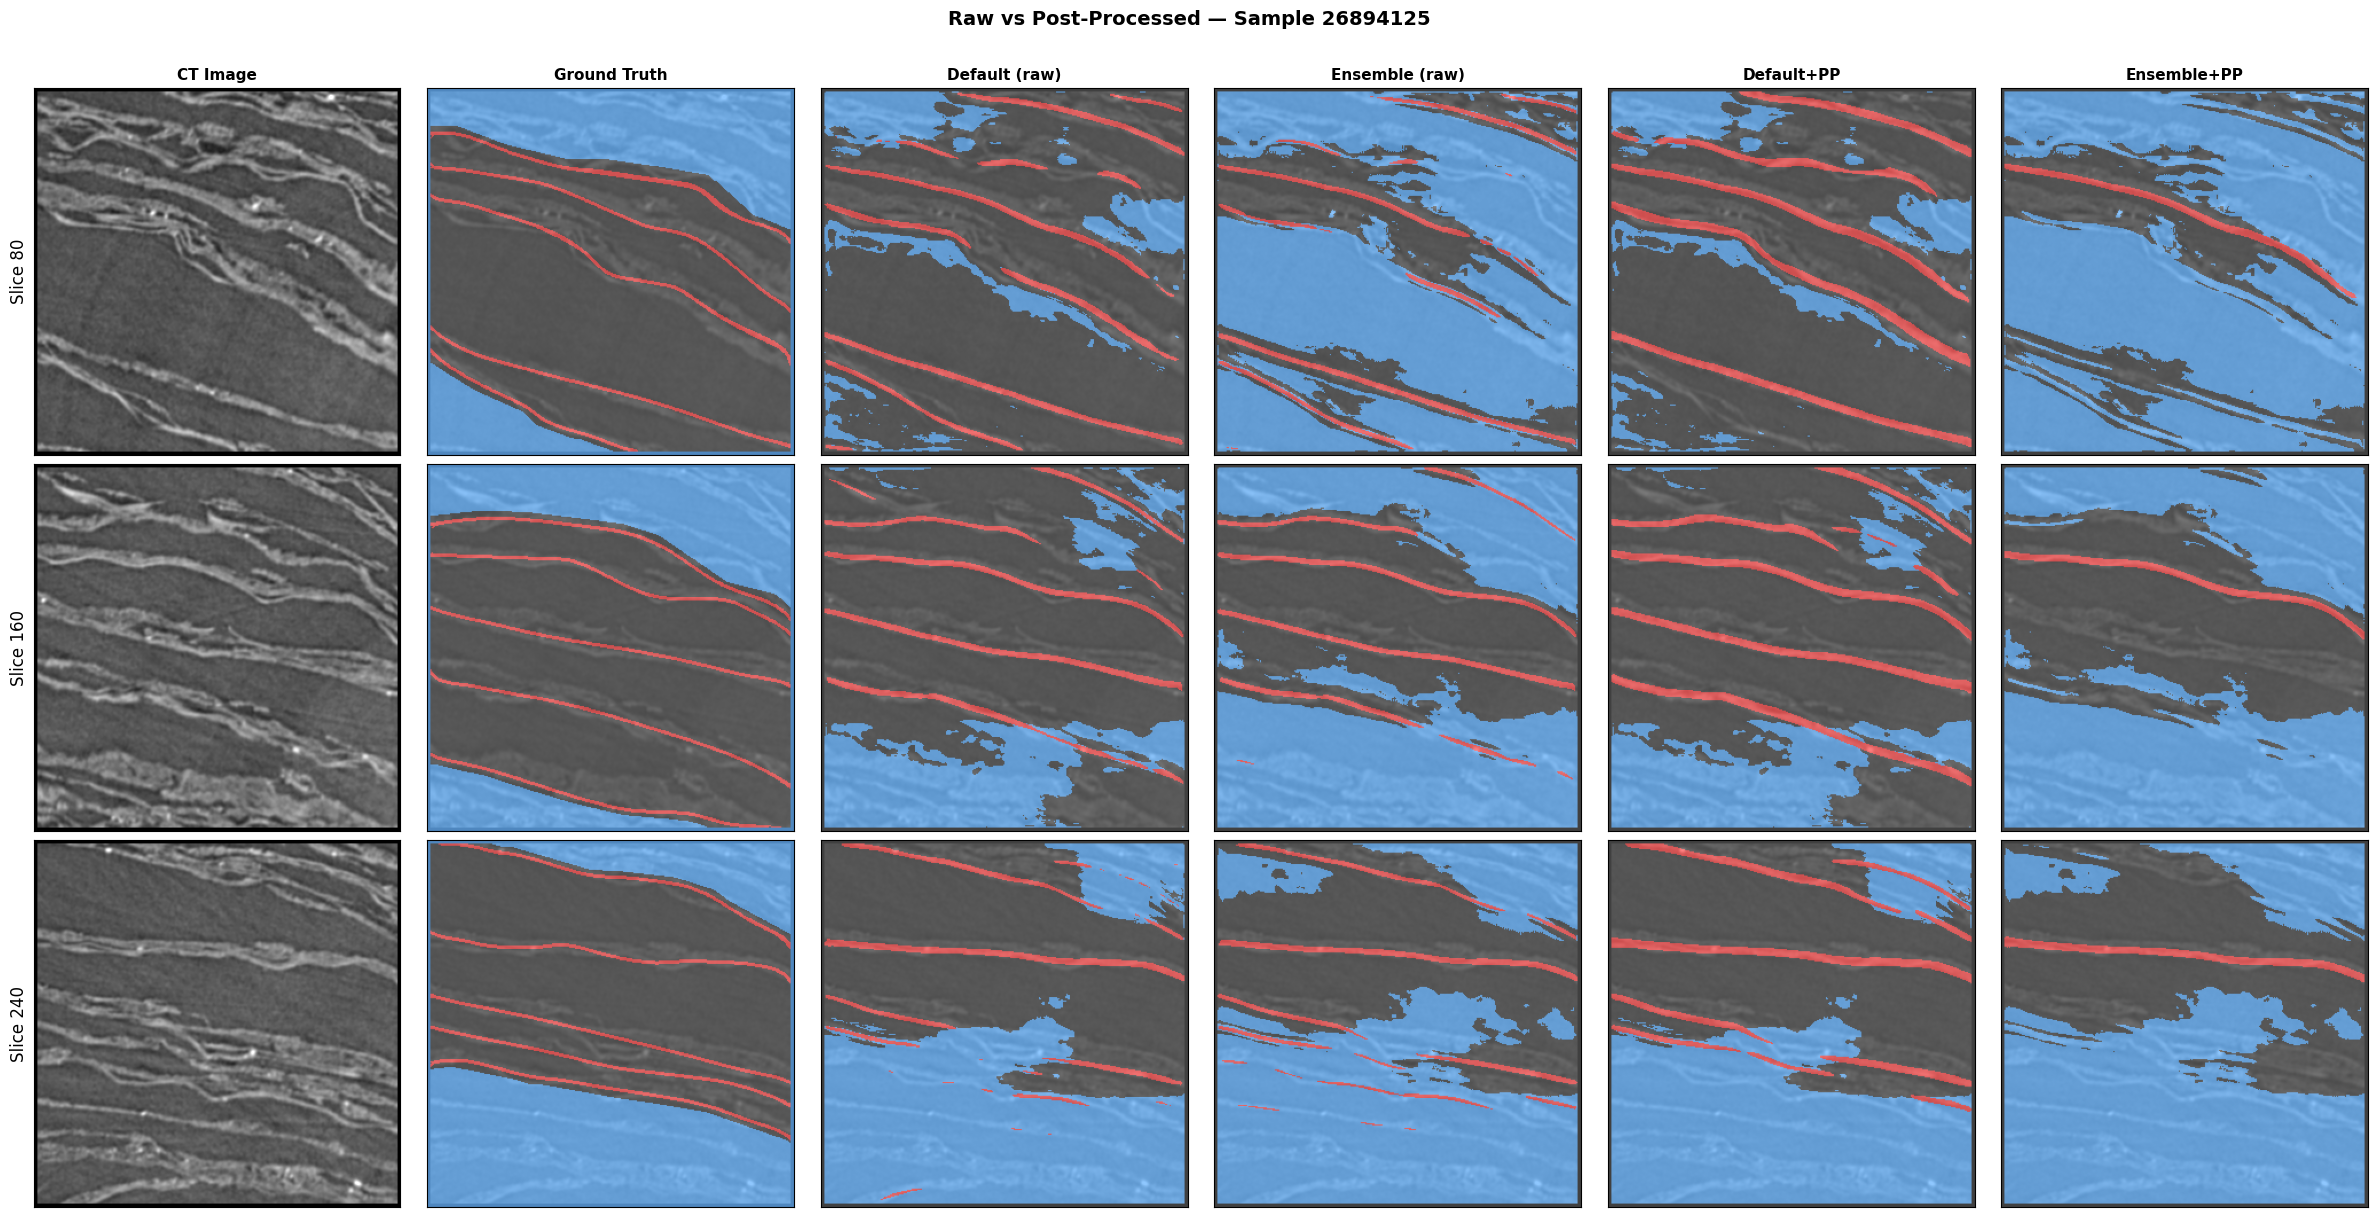

In [30]:
seg_cmap = ListedColormap(['black', 'red', 'dodgerblue'])

def plot_comparison(image, label, predictions, slice_fracs=[0.25, 0.5, 0.75], axis=0, title=''):
    n_slices = len(slice_fracs)
    n_cols = 2 + len(predictions)
    fig, axes = plt.subplots(n_slices, n_cols, figsize=(4 * n_cols, 4 * n_slices))
    col_titles = ['CT Image', 'Ground Truth'] + list(predictions.keys())
    for row, frac in enumerate(slice_fracs):
        idx = int(frac * image.shape[axis])
        img_slice = np.take(image, idx, axis=axis)
        lbl_slice = np.take(label, idx, axis=axis)
        axes[row, 0].imshow(img_slice, cmap='gray')
        axes[row, 0].set_ylabel(f'Slice {idx}', fontsize=12)
        axes[row, 1].imshow(img_slice, cmap='gray', alpha=0.5)
        axes[row, 1].imshow(lbl_slice, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=2)
        for col, (name, pred) in enumerate(predictions.items(), start=2):
            pred_slice = np.take(pred, idx, axis=axis)
            axes[row, col].imshow(img_slice, cmap='gray', alpha=0.5)
            axes[row, col].imshow(pred_slice, cmap=seg_cmap, alpha=0.5, vmin=0, vmax=2)
        for col in range(n_cols):
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    for col, t in enumerate(col_titles):
        axes[0, col].set_title(t, fontsize=11, fontweight='bold')
    plt.suptitle(title or f'Sample {SAMPLE_ID}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'/raid/home/vikram_govt/Dikshant/gautam/cv/notebooks/comparison_{SAMPLE_ID}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Show: Raw vs Post-Processed
plot_comparison(image, label_gt, {
    'Default (raw)': pred_raw_default,
    'Ensemble (raw)': pred_raw_ensemble,
    'Default+PP': pred_pp_default_3c,
    'Ensemble+PP': pred_pp_ensemble_3c,
}, title=f'Raw vs Post-Processed — Sample {SAMPLE_ID}')

## 7. Surface Probability Heatmaps

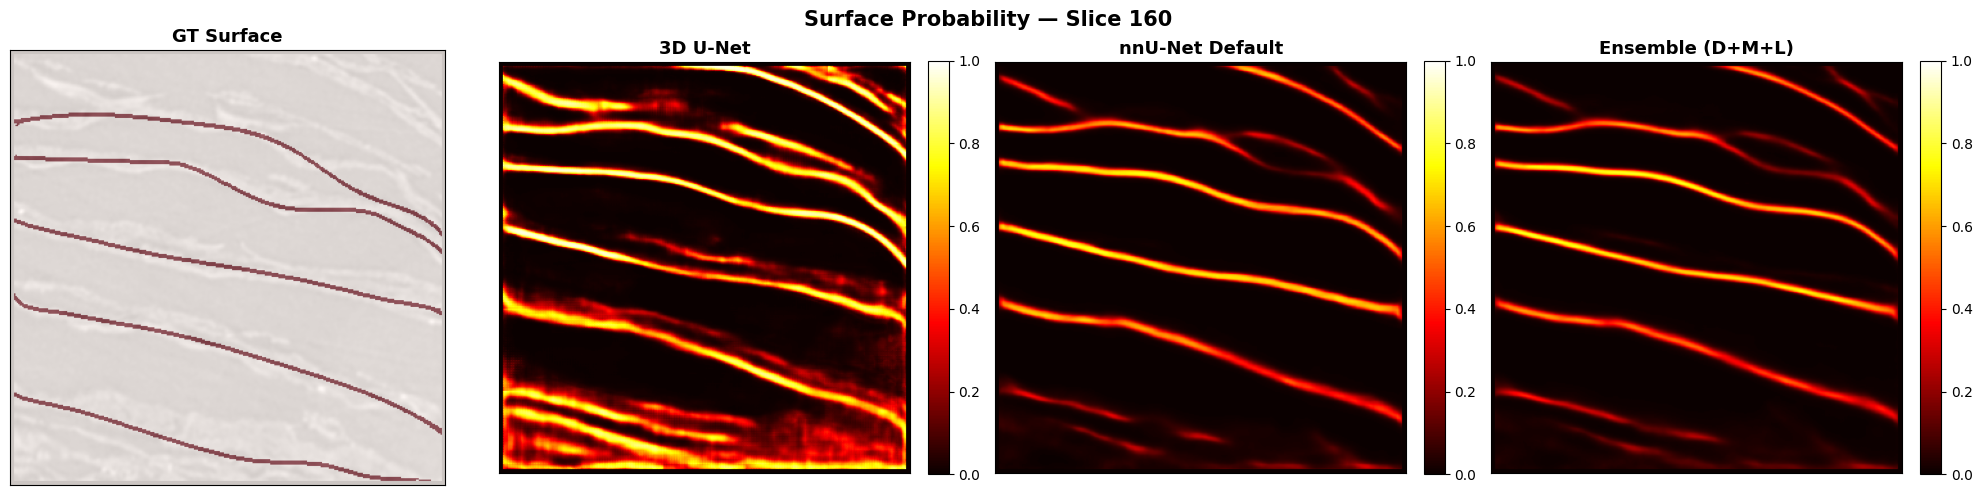

In [31]:
def plot_surface_probability(image, label, prob_maps, slice_frac=0.5, axis=0):
    idx = int(slice_frac * image.shape[axis])
    n_cols = 1 + len(prob_maps)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
    lbl_slice = np.take(label, idx, axis=axis)
    img_slice = np.take(image, idx, axis=axis)
    axes[0].imshow(img_slice, cmap='gray', alpha=0.5)
    axes[0].imshow(lbl_slice == 1, cmap='Reds', alpha=0.6)
    axes[0].set_title('GT Surface', fontsize=13, fontweight='bold')
    axes[0].set_xticks([]); axes[0].set_yticks([])
    for i, (name, prob) in enumerate(prob_maps.items(), start=1):
        prob_slice = np.take(prob, idx, axis=axis)
        im = axes[i].imshow(prob_slice, cmap='hot', vmin=0, vmax=1)
        axes[i].set_title(name, fontsize=13, fontweight='bold')
        axes[i].set_xticks([]); axes[i].set_yticks([])
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    plt.suptitle(f'Surface Probability — Slice {idx}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/raid/home/vikram_govt/Dikshant/gautam/cv/notebooks/surface_prob_{SAMPLE_ID}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_surface_probability(image, label_gt, {
    '3D U-Net': surf_prob_unet,
    'nnU-Net Default': probs_default[1],
    'Ensemble (D+M+L)': surf_prob_ensemble,
}, slice_frac=0.5)

## 8. Per-Slice Surface Dice

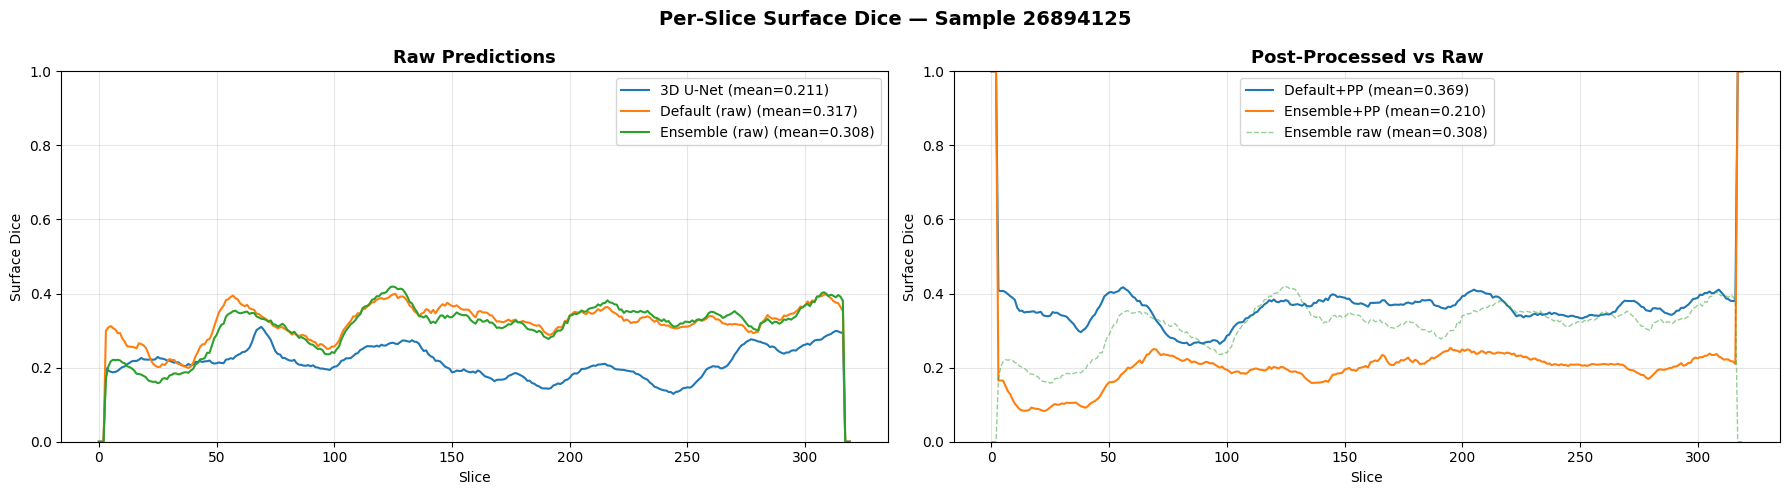

In [32]:
def per_slice_dice(pred, gt, target_class=1, axis=0):
    n_slices = gt.shape[axis]
    dices = []
    for i in range(n_slices):
        p = np.take(pred, i, axis=axis) == target_class
        g = np.take(gt, i, axis=axis) == target_class
        intersection = (p & g).sum()
        union = p.sum() + g.sum()
        dice = (2 * intersection) / (union + 1e-8) if union > 0 else 1.0
        dices.append(dice)
    return np.array(dices)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Left: Raw models
for name, pred in [('3D U-Net', pred_raw_unet), ('Default (raw)', pred_raw_default), 
                    ('Ensemble (raw)', pred_raw_ensemble)]:
    d = per_slice_dice(pred, label_gt)
    ax1.plot(d, label=f'{name} (mean={d.mean():.3f})', linewidth=1.5)
ax1.set_title('Raw Predictions', fontsize=13, fontweight='bold')
ax1.set_xlabel('Slice'); ax1.set_ylabel('Surface Dice')
ax1.legend(); ax1.set_ylim(0, 1); ax1.grid(True, alpha=0.3)

# Right: Post-processed
for name, pred in [('Default+PP', pred_pp_default_3c), ('Ensemble+PP', pred_pp_ensemble_3c)]:
    d = per_slice_dice(pred, label_gt)
    ax2.plot(d, label=f'{name} (mean={d.mean():.3f})', linewidth=1.5)
d_gt = per_slice_dice(pred_raw_ensemble, label_gt)
ax2.plot(d_gt, label=f'Ensemble raw (mean={d_gt.mean():.3f})', linewidth=1, linestyle='--', alpha=0.5)
ax2.set_title('Post-Processed vs Raw', fontsize=13, fontweight='bold')
ax2.set_xlabel('Slice'); ax2.set_ylabel('Surface Dice')
ax2.legend(); ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Per-Slice Surface Dice — Sample {SAMPLE_ID}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'/raid/home/vikram_govt/Dikshant/gautam/cv/notebooks/per_slice_dice_{SAMPLE_ID}.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Effect of Threshold Tuning

/tmp/ipykernel_1141853/1271927481.py:53: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask.astype(bool), min_size=dust_min_size)
/tmp/ipykernel_1141853/3175845526.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask.astype(bool), min_size=1000).astype(n

T_low=0.10: surface_dice=0.2103, mean_dice=0.4659
T_low=0.15: surface_dice=0.2036, mean_dice=0.4643
T_low=0.20: surface_dice=0.1956, mean_dice=0.4621
T_low=0.25: surface_dice=0.1868, mean_dice=0.4595
T_low=0.30: surface_dice=0.1767, mean_dice=0.4564
T_low=0.35: surface_dice=0.1658, mean_dice=0.4530
T_low=0.40: surface_dice=0.1536, mean_dice=0.4491
T_low=0.50: surface_dice=0.1240, mean_dice=0.4396


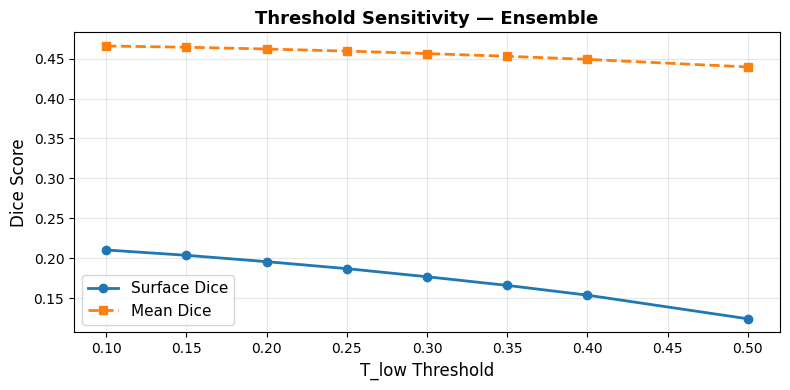

In [33]:
# Sweep T_low to find optimal threshold
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
results = []

for t in thresholds:
    mask = topo_postprocess(surf_prob_ensemble, T_low=t, T_high=0.83, z_radius=1, xy_radius=1)
    mask = zero_volume_faces(mask, 3)
    mask = remove_small_objects(mask.astype(bool), min_size=1000).astype(np.uint8)
    pred_3c = surface_to_3class(mask, probs_ensemble[0], probs_ensemble[2])
    r = compute_metrics(pred_3c, label_gt)
    results.append((t, r['surface_dice'], r['mean_dice']))
    print(f'T_low={t:.2f}: surface_dice={r["surface_dice"]:.4f}, mean_dice={r["mean_dice"]:.4f}')

ts, sds, mds = zip(*results)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, sds, 'o-', label='Surface Dice', linewidth=2)
ax.plot(ts, mds, 's--', label='Mean Dice', linewidth=2)
ax.set_xlabel('T_low Threshold', fontsize=12)
ax.set_ylabel('Dice Score', fontsize=12)
ax.set_title('Threshold Sensitivity — Ensemble', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'/raid/home/vikram_govt/Dikshant/gautam/cv/notebooks/threshold_sweep_{SAMPLE_ID}.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

In [34]:
print('=' * 70)
print('  RESULTS SUMMARY')
print('=' * 70)
print()
print('Inference-time improvements applied:')
print('  1. Ensemble: weighted fusion of Default + MPlans + LPlans')
print('  2. Hysteresis thresholding (T_low=0.2, T_high=0.83)')
print('  3. Anisotropic closing + dust removal')
print('  4. Binary closing (ball r=3) + per-slice/3D hole filling')
print('  5. PCA-based sheet interpolation for topology repair')
print()
print('Final metrics on sample volume:')
print(f'{"Model":<30} {"Surface Dice":>13} {"Mean Dice":>10}')
print('-' * 55)
for name, pred in all_preds.items():
    r = compute_metrics(pred, label_gt)
    print(f'{name:<30} {r["surface_dice"]:>13.4f} {r["mean_dice"]:>10.4f}')

  RESULTS SUMMARY

Inference-time improvements applied:
  1. Ensemble: weighted fusion of Default + MPlans + LPlans
  2. Hysteresis thresholding (T_low=0.2, T_high=0.83)
  3. Anisotropic closing + dust removal
  4. Binary closing (ball r=3) + per-slice/3D hole filling
  5. PCA-based sheet interpolation for topology repair

Final metrics on sample volume:
Model                           Surface Dice  Mean Dice
-------------------------------------------------------
3D U-Net (raw)                        0.2098     0.3292
nnU-Net Default (raw)                 0.3209     0.5503
Ensemble raw (D+M+L)                  0.3136     0.5002
nnU-Net Default + PostProc            0.3571     0.5600
Ensemble + PostProc                   0.1956     0.4621
